## SETUP

In [ ]:
import os
import random
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib

%matplotlib inline
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
import timm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


In [3]:
# 1. Copy file zip từ Drive xuống Colab
!cp "/content/drive/MyDrive/derm7pt.zip" "/content/"

# 2. Tạo thư mục và giải nén
!mkdir -p /content/data_derm7pt
!unzip -q /content/derm7pt.zip -d /content/data_derm7pt

# 3. Dọn rác
!rm /content/derm7pt.zip

In [ ]:
SEED           = 42
IMG_SIZE       = 224
BATCH_SIZE     = 16
NUM_EPOCHS_FT  = 25
LR_HEAD        = 3e-4
LR_BACKBONE    = 1e-5
NUM_CLASSES_SRC = 7
NUM_CLASSES_TGT = 5
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path('/content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT')

DERM_DIR = Path('/content/data_derm7pt/derm7pt/release_v0')
SPLIT_DIR  = PROJECT_ROOT / 'data' / 'splits'
CKPT_DIR   = PROJECT_ROOT / 'checkpoints'
LOG_DIR    = PROJECT_ROOT / 'logs'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'ph05_vit_transfer_outputs'

for d in [CKPT_DIR, LOG_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Nhãn Derm7pt sau mapping từ notebook 02 & 03
LABEL2IDX_DERM = {'bcc': 0, 'mel': 1, 'misc': 2, 'nevus': 3, 'sk': 4}
IDX2LABEL_DERM = {v: k for k, v in LABEL2IDX_DERM.items()}

print('Cấu hình hoàn tất.')

Cấu hình hoàn tất.


## LOAD SPLIT DERM7PT

In [5]:
import os
import pandas as pd

df_train = pd.read_csv(SPLIT_DIR / 'derm7pt_train.csv')
df_val   = pd.read_csv(SPLIT_DIR / 'derm7pt_val.csv')
df_test  = pd.read_csv(SPLIT_DIR / 'derm7pt_test.csv')

for df_split in [df_train, df_val, df_test]:
    if 'label_idx' not in df_split.columns:
        df_split['label_idx'] = df_split['label'].map(LABEL2IDX_DERM)

# 1. Quét toàn bộ ảnh thực tế đang có trên Colab
print("Đang quét ổ đĩa Colab để thiết lập đường dẫn chuẩn...")
real_image_paths = {}
for root, dirs, files in os.walk(DERM_DIR / 'images'):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Lưu key là tên file in thường (để chống lỗi hoa/thường)
            # Value là đường dẫn tuyệt đối chuẩn xác 100% của Linux
            real_image_paths[file.lower()] = os.path.join(root, file).replace('\\', '/')

# 2. Hàm siêu tìm kiếm file
def get_real_path(csv_path):
    # Chỉ lấy tên file cuối cùng từ CSV và in thường (VD: FCl068.jpg -> fcl068.jpg)
    filename = str(csv_path).replace('\\', '/').split('/')[-1].lower()

    # Tìm tên file trong từ điển đường dẫn thực tế
    return real_image_paths.get(filename, None)

# 3. Áp dụng đồng loạt cho 3 tập
df_train['img_path'] = df_train['img_path'].apply(get_real_path)
df_val['img_path']   = df_val['img_path'].apply(get_real_path)
df_test['img_path']  = df_test['img_path'].apply(get_real_path)

# Dọn dẹp nếu có file nào thực sự không tồn tại
df_train = df_train.dropna(subset=['label_idx', 'img_path']).reset_index(drop=True)
df_val   = df_val.dropna(subset=['label_idx', 'img_path']).reset_index(drop=True)
df_test  = df_test.dropna(subset=['label_idx', 'img_path']).reset_index(drop=True)

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print("Đường dẫn test chuẩn Linux đã sửa:", df_train['img_path'].iloc[0])

Đang quét ổ đĩa Colab để thiết lập đường dẫn chuẩn...
Train: 413 | Val: 203 | Test: 395
Đường dẫn test chuẩn Linux đã sửa: /content/data_derm7pt/derm7pt/release_v0/images/NEL/Nel026.jpg


## DATASET & DATALOADER

In [ ]:
# Augmentation mạnh hơn vì Derm7pt ít mẫu
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from transforms import get_vit_transforms

train_transform = get_vit_transforms('derm_train')
val_transform   = get_vit_transforms('val')

class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['img_path']).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = SkinDataset(df_train, transform=train_transform)
val_dataset   = SkinDataset(df_val,   transform=val_transform)
test_dataset  = SkinDataset(df_test,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 26 | Val: 13 | Test: 25


## CLASS WEIGHTS

In [ ]:
y_train = df_train['label_idx'].astype(int).values
class_weights_tensor = torch.load(SPLIT_DIR / 'derm7pt_class_weights.pt').to(DEVICE)
print('Class weights Derm7pt:', class_weights_tensor)

Class weights Derm7pt: [0.323 0.918 5.162 2.581 4.347]


## LOAD PRETRAINED ViT & THAY CLASSIFIER HEAD

In [8]:
model_vit = timm.create_model(
    'vit_base_patch16_224',
    pretrained=False,
    num_classes=NUM_CLASSES_SRC
)

ckpt_path = CKPT_DIR / 'vit_ham10000_best.pth'
if ckpt_path.exists():
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model_vit.load_state_dict(checkpoint['model_state_dict'])
    print(f'✅ Đã load checkpoint từ: {ckpt_path}')
    print(f'   Pretrain tốt nhất ở Epoch {checkpoint["epoch"]} — Val Acc: {checkpoint["val_acc"]:.4f}')
else:
    print('⚠️ Không tìm thấy checkpoint HAM10000! Dùng pretrained ImageNet thay thế.')
    model_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=NUM_CLASSES_SRC)

in_features = model_vit.head.in_features
model_vit.head = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, NUM_CLASSES_TGT)
)
model_vit = model_vit.to(DEVICE)

print(f'\nHead mới: {model_vit.head}')

for name, param in model_vit.named_parameters():
    if 'head' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_vit.parameters())
print(f'Warm-up — trainable: {trainable:,} / {total:,}')

✅ Đã load checkpoint từ: /content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT/checkpoints/vit_ham10000_best.pth
   Pretrain tốt nhất ở Epoch 17 — Val Acc: 0.8291

Head mới: Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=768, out_features=5, bias=True)
)
Warm-up — trainable: 3,845 / 85,802,501


## LOSS, OPTIMIZER, SCHEDULER

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model_vit.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS_FT, eta_min=1e-7)

WARMUP_EPOCHS = 3

## TRAIN / EVAL FUNCTIONS

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds         = outputs.argmax(1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)
    return running_loss / total, correct / total

## FINE-TUNING LOOP

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_epoch   = 0

with open(LOG_DIR / 'vit_derm7pt_finetune.log', 'w') as f:
    f.write('epoch,train_loss,train_acc,val_loss,val_acc\n')
    
print('\n' + '═'*60)
print('  BẮT ĐẦU FINE-TUNE ViT TRÊN DERM7PT')
print('═'*60)

for epoch in range(1, NUM_EPOCHS_FT + 1):

    if epoch == WARMUP_EPOCHS + 1:
        print(f'\n[Epoch {epoch}] Unfreeze toàn bộ — dùng Differential LR')
        for param in model_vit.parameters():
            param.requires_grad = True

        optimizer = optim.AdamW([
            {'params': [p for n, p in model_vit.named_parameters() if 'head' not in n], 'lr': LR_BACKBONE},
            {'params': model_vit.head.parameters(), 'lr': LR_HEAD},
        ], weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS_FT - WARMUP_EPOCHS, eta_min=1e-8
        )

    train_loss, train_acc = train_one_epoch(model_vit, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model_vit, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS_FT}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model_vit.state_dict(),
            'val_acc'          : val_acc,
            'val_loss'         : val_loss,
            'num_classes'      : NUM_CLASSES_TGT,
            'label2idx'        : LABEL2IDX_DERM,
        }, CKPT_DIR / 'vit_derm7pt_best.pth')
        print(f'  ✅ Lưu checkpoint — Val Acc: {best_val_acc:.4f}')

    with open(LOG_DIR / 'vit_derm7pt_finetune.log', 'a') as f:
        f.write(f'{epoch},{train_loss:.6f},{train_acc:.6f},{val_loss:.6f},{val_acc:.6f}\n')

print(f'\n🏆 Epoch tốt nhất: {best_epoch} — Val Acc: {best_val_acc:.4f}')


════════════════════════════════════════════════════════════
  BẮT ĐẦU FINE-TUNE ViT TRÊN DERM7PT
════════════════════════════════════════════════════════════
Epoch [01/20] Train Loss: 2.6512 | Train Acc: 0.3898 | Val Loss: 1.0591 | Val Acc: 0.6207
  ✅ Lưu checkpoint — Val Acc: 0.6207
Epoch [02/20] Train Loss: 1.2620 | Train Acc: 0.6053 | Val Loss: 0.8000 | Val Acc: 0.6798
  ✅ Lưu checkpoint — Val Acc: 0.6798
Epoch [03/20] Train Loss: 0.9701 | Train Acc: 0.6247 | Val Loss: 0.7651 | Val Acc: 0.7044
  ✅ Lưu checkpoint — Val Acc: 0.7044

[Epoch 4] Unfreeze toàn bộ — dùng Differential LR
Epoch [04/20] Train Loss: 1.2835 | Train Acc: 0.6029 | Val Loss: 0.9705 | Val Acc: 0.6305
Epoch [05/20] Train Loss: 0.8193 | Train Acc: 0.6634 | Val Loss: 0.7179 | Val Acc: 0.7537
  ✅ Lưu checkpoint — Val Acc: 0.7537
Epoch [06/20] Train Loss: 0.6716 | Train Acc: 0.7530 | Val Loss: 0.6809 | Val Acc: 0.7488
Epoch [07/20] Train Loss: 0.5159 | Train Acc: 0.7579 | Val Loss: 0.8208 | Val Acc: 0.6995
Epoch [08/2

## VISUALIZATION

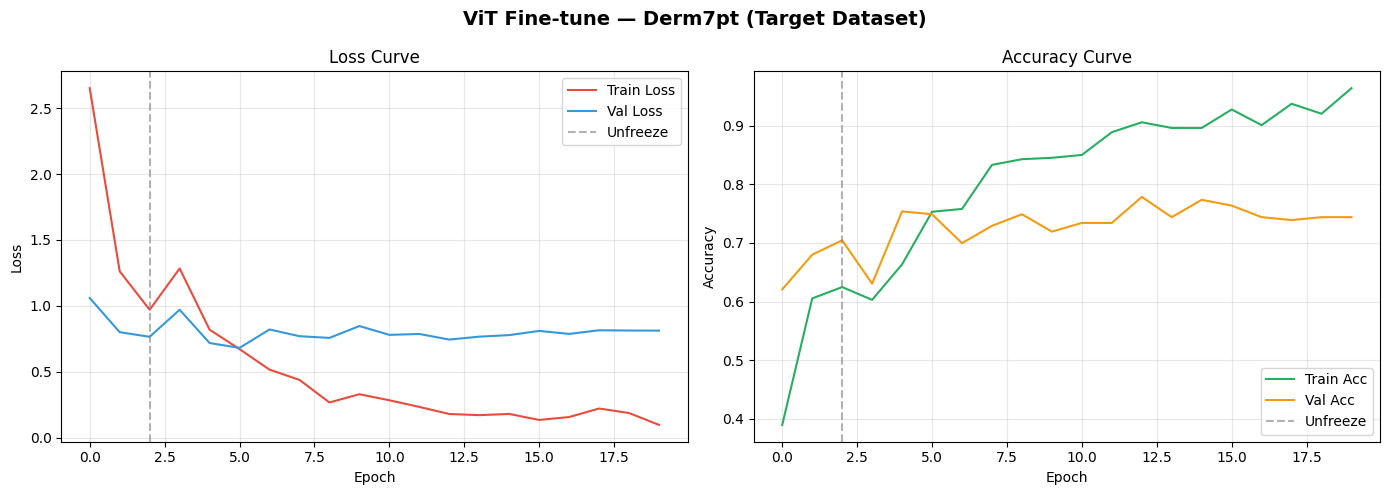

Đã lưu biểu đồ tại: /content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT/results/ph05_vit_transfer_outputs/vit_derm7pt_finetune_curves.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ViT Fine-tune — Derm7pt (Target Dataset)', fontsize=14, fontweight='bold')

axes[0].plot(history['train_loss'], label='Train Loss', color='#E74C3C')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#3498DB')
axes[0].axvline(WARMUP_EPOCHS - 1, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', color='#27AE60')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='#F39C12')
axes[1].axvline(WARMUP_EPOCHS - 1, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'vit_derm7pt_finetune_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu biểu đồ tại: {OUTPUT_DIR}/vit_derm7pt_finetune_curves.png')

✅ Loaded best checkpoint — Val Acc: 0.7783 (Epoch 13)


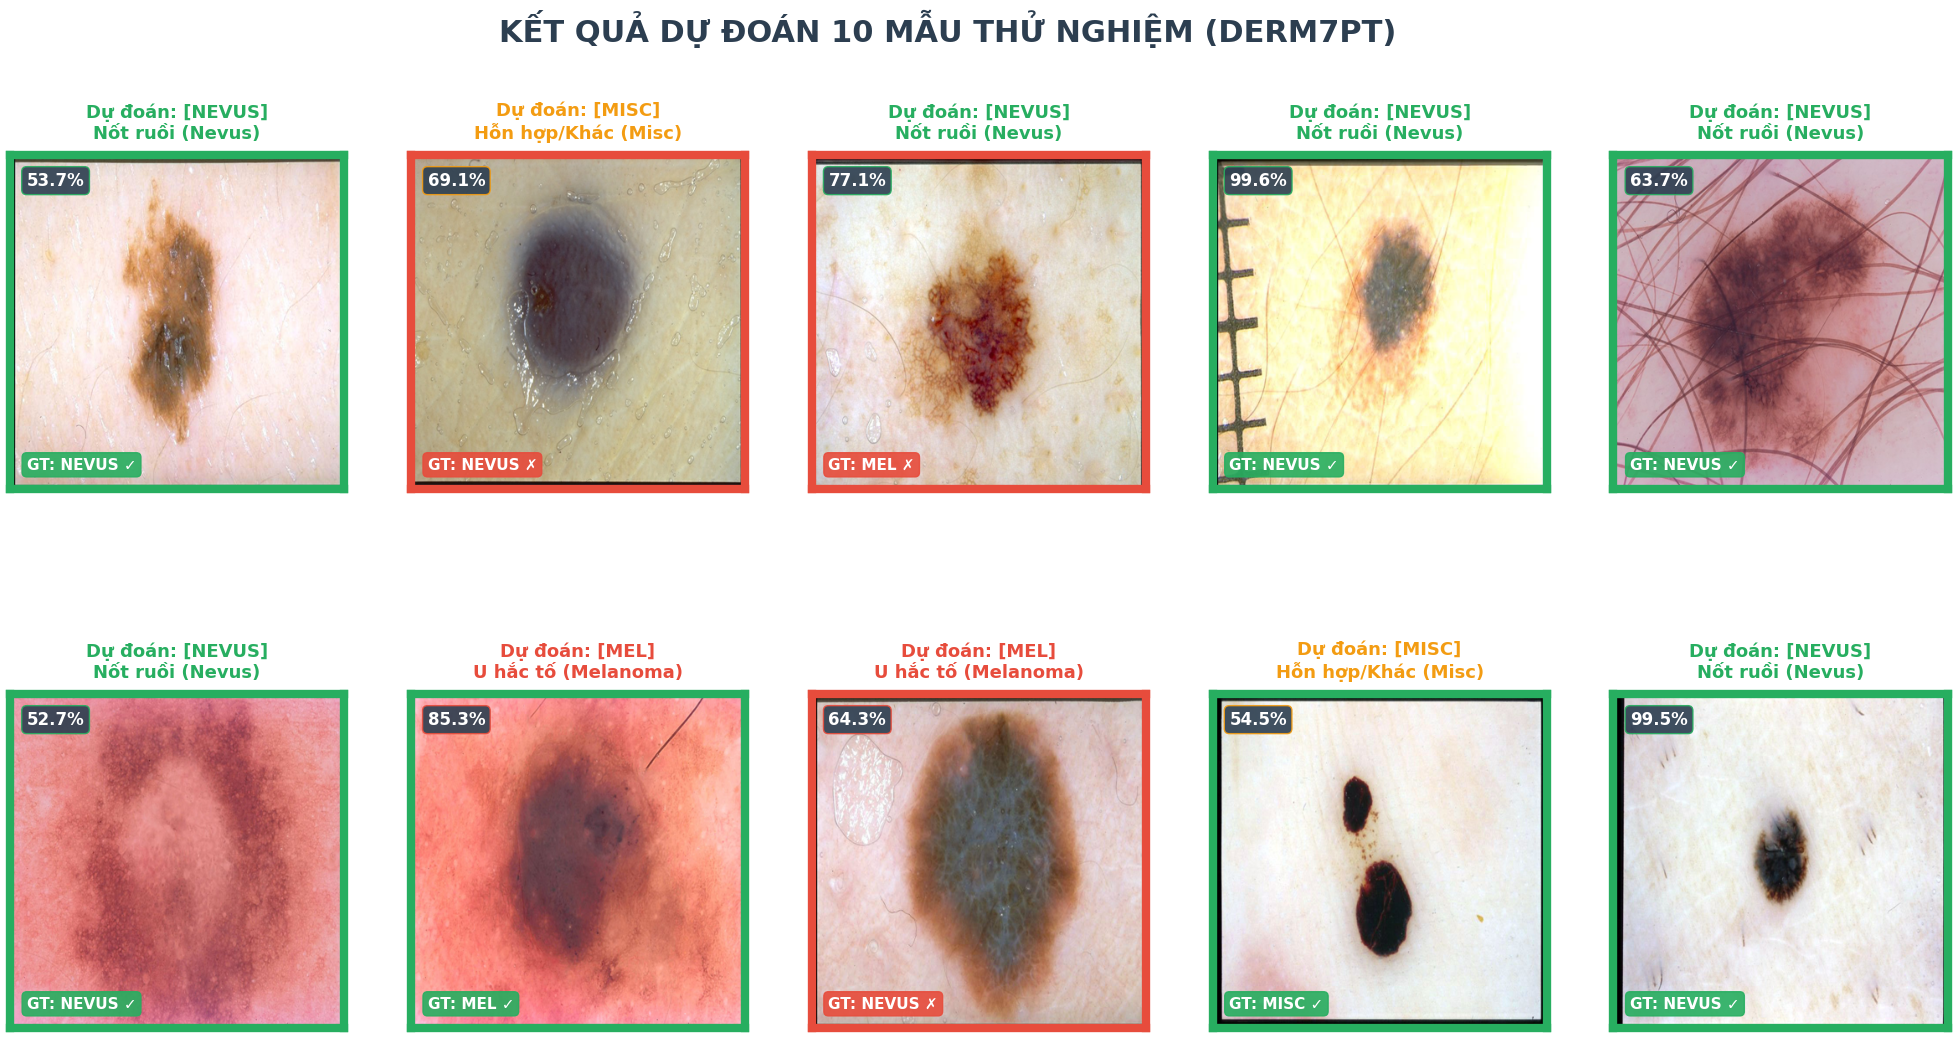

💾 Đã lưu ảnh kết quả dự đoán tại: /content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT/results/ph05_vit_transfer_outputs/vit_derm7pt_predictions.png


In [ ]:
# 1. LOAD BEST CHECKPOINT DERM7PT
best_ckpt_path = CKPT_DIR / 'vit_derm7pt_best.pth'
best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model_vit.load_state_dict(best_ckpt['model_state_dict'])
model_vit.eval()
print(f'✅ Loaded best checkpoint — Val Acc: {best_ckpt["val_acc"]:.4f} (Epoch {best_ckpt["epoch"]})')

# 2. CONFIG FOR DERM7PT (Adapted from reference)
LABEL_INFO_DERM = {
    'nevus': {'vn': 'Nốt ruồi (Nevus)', 'risk': 'Lành tính'},
    'mel'  : {'vn': 'U hắc tố (Melanoma)', 'risk': 'Ác tính'},
    'sk'   : {'vn': 'Dày sừng (Seb. Keratosis)', 'risk': 'Lành tính'},
    'bcc'  : {'vn': 'Ung thư tế bào đáy (BCC)', 'risk': 'Ác tính'},
    'misc' : {'vn': 'Hỗn hợp/Khác (Misc)', 'risk': 'Cần lưu ý'}
}
RISK_COLOR = {'Ác tính': '#E74C3C', 'Cần lưu ý': '#F39C12', 'Lành tính': '#27AE60'}

infer_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# 3. PREDICT 10 SAMPLES FROM DERM7PT VAL SET
sample_10 = df_val.sample(10, random_state=SEED).reset_index(drop=True)
results = []

with torch.no_grad():
    for _, row in sample_10.iterrows():
        img_pil = Image.open(row['img_path']).convert('RGB')
        input_tensor = infer_transform(img_pil).unsqueeze(0).to(DEVICE)
        outputs = model_vit(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

        pred_label = IDX2LABEL_DERM[pred_idx.item()]
        gt_label = row['label'] # Label gốc chuỗi

        results.append({
            'img_pil': img_pil,
            'pred': pred_label,
            'gt': gt_label,
            'conf': conf.item() * 100,
            'correct': (pred_label == gt_label)
        })

# 4. VISUALIZE 2 ROWS x 5 COLS
fig, axes = plt.subplots(2, 5, figsize=(25, 12))
fig.patch.set_facecolor('#FFFFFF')
fig.suptitle('KẾT QUẢ DỰ ĐOÁN 10 MẪU THỬ NGHIỆM (DERM7PT)', fontsize=22, fontweight='bold', color='#2C3E50', y=0.98)

axes_flat = axes.flatten()
for i, r in enumerate(results):
    ax = axes_flat[i]
    info = LABEL_INFO_DERM.get(r['pred'], {'vn': r['pred'], 'risk': 'Lành tính'})
    pred_color = RISK_COLOR.get(info['risk'], '#34495E')
    border_col = '#27AE60' if r['correct'] else '#E74C3C'

    ax.imshow(r['img_pil'].resize((400, 400)))
    ax.set_xticks([]); ax.set_yticks([])

    # Drawing borders
    for spine in ax.spines.values():
        spine.set_edgecolor(border_col)
        spine.set_linewidth(6)

    # Prediction Text
    ax.set_title(f"Dự đoán: [{r['pred'].upper()}]\n{info['vn']}",
                 fontsize=13, fontweight='bold', color=pred_color, pad=12)

    # Confidence badge
    ax.text(0.05, 0.95, f"{r['conf']:.1f}%", transform=ax.transAxes, fontsize=12,
            fontweight='bold', color='white', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='#2C3E50', ec=pred_color, alpha=0.9))

    # Ground Truth badge
    gt_col = '#27AE60' if r['correct'] else '#E74C3C'
    ax.text(0.05, 0.05, f"GT: {r['gt'].upper()} {'✓' if r['correct'] else '✗'}",
            transform=ax.transAxes, fontsize=11, fontweight='bold', color='white', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', fc=gt_col, ec=gt_col, alpha=0.9))

plt.subplots_adjust(hspace=0.4, wspace=0.2)

# 5. SAVE AND SHOW
save_path = OUTPUT_DIR / 'vit_derm7pt_predictions.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#FFFFFF')
plt.show()
print(f'💾 Đã lưu ảnh kết quả dự đoán tại: {save_path}')